<a href="https://colab.research.google.com/github/obrazjr/MVP_BreastCancer/blob/main/OtavioBraz_MVP_ML_Cancer_Mama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


*Machine Learning & Analytics*

**Autor:** OTÁVIO BRAZ RIBEIRO JUNIOR

**Data:** 27/08/2025

**Matrícula:** 4052025001133

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset https://raw.githubusercontent.com/obrazjr/MVP_BreastCancer/main/breast_cancer_wisconsin.csv

**Modelo resultante**: https://raw.githubusercontent.com/obrazjr/MVP_BreastCancer/main/modelo_breast_cancer.pkl



## 1. Escopo, objetivo e definição do problema

O presente trabalho utiliza o **Breast Cancer Wisconsin (Diagnostic) Dataset**, que reúne medições de células da mama a partir de imagens digitalizadas.  
O objetivo é construir um modelo preditivo capaz de **classificar tumores mamários em benignos ou malignos**, apoiando o diagnóstico médico.  

- **Tipo de tarefa:** Classificação binária (0 = maligno, 1 = benigno).  
- **Área de aplicação:** Dados tabulares na área de saúde (oncologia).  
- **Valor para o usuário/negócio:** um sistema desse tipo pode auxiliar profissionais da saúde a **priorizar exames e decisões clínicas**, reduzindo erros e agilizando a triagem de pacientes. Embora não substitua o médico, fornece **apoio à decisão** com base em aprendizado de máquina.


## 2. Reprodutibilidade e ambiente

Para este projeto, foi definido um ambiente simples e reprodutível:

- **Bibliotecas utilizadas**:  
  - `numpy` e `pandas` para manipulação de dados  
  - `matplotlib` para visualização  
  - `scikit-learn` para divisão treino/teste, modelos de classificação e métricas  

- **Seed fixa**:  
  - Foi definido `SEED = 42` para garantir reprodutibilidade nos experimentos.  
  - A seed foi aplicada tanto para `numpy` quanto para `random`


In [ ]:
# === Setup p/ classificação binária ===
import os, sys, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Seed global
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)


Python: 3.12.11
Seed global: 42



### 2.1 Dependências

In [ ]:

!pip install -q scikit-learn matplotlib pandas
!pip install -q seaborn imbalanced-learn



### 2.2 Função de avaliação

A função `evaluate_classification` serve para calcular as métricas principais do modelo:  
- **Accuracy**: acertos totais  
- **F1 Score**: equilíbrio entre precisão e recall  
- **ROC AUC**: separação entre as classes


In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")
    auc = roc_auc_score(y_true, proba[:,1]) if (proba is not None and proba.shape[1]==2) else np.nan
    return {"accuracy": acc, "f1_weighted": f1w, "roc_auc": auc}

## 3. Dados: carga, entendimento e qualidade

O dataset utilizado é o Breast Cancer Wisconsin (Diagnostic), disponível no UCI.  
Ele contém medidas numéricas extraídas de imagens de células da mama (ex.: raio, textura, suavidade).  
A variável alvo é diagnosis:  
- M = maligno  
- B = benigno  

O conjunto possui 569 amostras e 30 variáveis numéricas.  
É público, destinado a pesquisa e ensino, sem dados pessoais identificáveis.  

Serão verificadas a existência de valores nulos, registros duplicados e o balanceamento das classes para garantir a qualidade e evitar vazamento de informação.


In [ ]:

# === Carga dos dados ===

url = "https://raw.githubusercontent.com/obrazjr/MVP_BreastCancer/main/breast_cancer_wisconsin.csv"
df = pd.read_csv(url)

print("Formato:", df.shape)
print("\nVisão inicial:")
display(df.head())

print("\nInfo:")
df.info()

print("\nResumo estatístico:")
df.describe()



Formato: (569, 31)

Visão inicial:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error   

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:

# === Verificações iniciais ===
display(df.sample(5))
print("\nFormato:", df.shape)
print("\nTipos:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
204,12.47,18.60,81.09,481.9,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,...,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.10150,0.3014,0.08750,1
70,18.94,21.31,123.60,1130.0,0.09009,0.1029,0.10800,0.07951,0.1582,0.05461,...,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.17890,0.2551,0.06589,0
131,15.46,19.48,101.70,748.9,0.10920,0.1223,0.14660,0.08087,0.1931,0.05796,...,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.15140,0.2837,0.08019,0
431,12.40,17.68,81.47,467.8,0.10540,0.1316,0.07741,0.02799,0.1811,0.07102,...,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.07370,0.2556,0.09359,1
540,11.54,14.44,74.65,402.9,0.09984,0.1120,0.06737,0.02594,0.1818,0.06782,...,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134,1



Formato: (569, 31)

Tipos:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       

### 3.1 Estrutura dos dados

- 569 linhas e 31 colunas (30 atributos + alvo).  
- Todas as variáveis de entrada são numéricas.  
- A coluna target é o rótulo (0 = benigno, 1 = maligno).  
- Não há valores ausentes.  


In [ ]:
print("Formato:", df.shape)
print("\nTipos:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Formato: (569, 31)

Tipos:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       f

### 3.2 Análise exploratória resumida (EDA)

O dataset é formado apenas por variáveis numéricas.  
Foram verificados a distribuição de algumas features e o balanceamento da variável alvo (target).  

- As variáveis numéricas apresentam distribuições concentradas em faixas específicas, com alguns outliers.  
- A variável alvo está desbalanceada, com mais casos benignos que malignos. Esse ponto será considerado na modelagem.

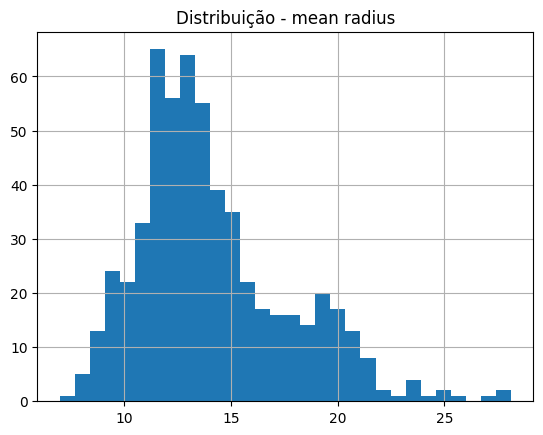

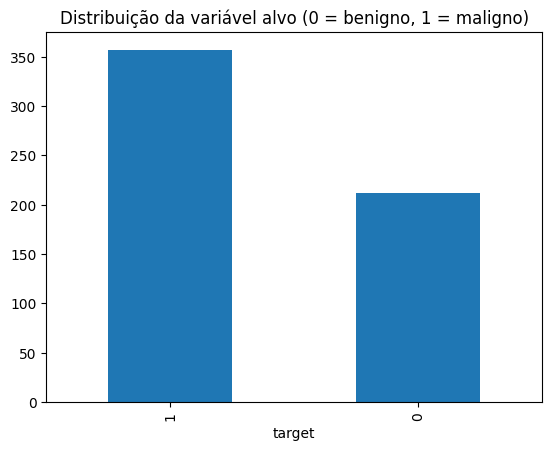

In [ ]:
# Distribuição de uma feature numérica (exemplo)
df["mean radius"].hist(bins=30)
plt.title("Distribuição - mean radius")
plt.show()

# Balanceamento da variável alvo
df["target"].value_counts().plot(kind="bar")
plt.title("Distribuição da variável alvo (0 = benigno, 1 = maligno)")
plt.show()


## 4. Definição do target, variáveis e divisão dos dados

Aqui o problema é de classificação binária.  
O **target** é a coluna `target` (0 = benigno, 1 = maligno).  
As outras colunas ficam como variáveis de entrada.  
Os dados foram separados em 80% treino e 20% teste, mantendo a proporção entre as classes.
.


In [ ]:
# === Definição do target e divisão dos dados ===

PROBLEM_TYPE = "classificacao"

# Definição de target e features
target = "target"
features = [c for c in df.columns if c != target]

X = df[features].copy()
y = df[target].copy()

# Divisão em treino e teste (80/20), com estratificação para manter a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Target:", target)
print("N features:", len(features))
print("Treino:", X_train.shape, "| Teste:", X_test.shape)


Target: target
N features: 30
Treino: (455, 30) | Teste: (114, 30)


### 4.1. Resultado da divisão
- 30 variáveis usadas como entrada  
- target = coluna `target` (0 = benigno, 1 = maligno)  
- treino: 455 linhas  
- teste: 114 linhas  


## 5. Tratamento de dados e Pipeline de pré-processamento

No dataset do câncer de mama todas as variáveis já são numéricas e não há valores ausentes.  
O único ajuste importante é a padronização (StandardScaler), que ajuda modelos como Regressão Logística.  

In [ ]:
# === Pipeline de pré-processamento + modelo ===
# 1. padroniza os dados (StandardScaler)
# 2. treina o modelo (LogisticRegression)


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=1000, random_state=SEED))
])

# treino
pipe.fit(X_train, y_train)

# teste
preds = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)

# métricas
metrics = evaluate_classification(y_test, preds, proba)
print(metrics)

# Pré-processamento simples para dados numéricos
from sklearn.preprocessing import StandardScaler

preprocess = StandardScaler()


{'accuracy': 0.9824561403508771, 'f1_weighted': 0.9824561403508771, 'roc_auc': np.float64(0.9953703703703703)}


### 5.1. Resultados iniciais

O modelo de Regressão Logística atingiu **98% de acurácia** e **ROC AUC próximo de 1.0**.  
Esse desempenho alto é esperado nesse dataset porque ele é bem limpo, balanceado e com variáveis que separam bem os casos benignos e malignos.  
Será testado também o **Random Forest**, para comparar com um modelo baseado em árvores e verificar se há ganho em desempenho ou robustez.  


## 6. Baseline e modelos candidatos

A baseline foi feita com o `DummyClassifier`, que só prevê a classe mais frequente.  
Isso serve como referência mínima de desempenho.  

Em seguida foram testados dois modelos candidatos:  
- **Logistic Regression**, que precisa de padronização dos dados.  
- **Random Forest**, que funciona bem mesmo sem padronização.  

As métricas (accuracy, F1 e ROC AUC) foram usadas para comparar com a baseline e mostrar o ganho real dos modelos.


In [ ]:
# === Baseline e modelos candidatos (classificação) ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("pre", StandardScaler()),  # só escala os dados
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline([
            ("pre", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=SEED))
        ]),
        "RandomForest": Pipeline([
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

# treino da baseline
baseline.fit(X_train, y_train)
preds_base = baseline.predict(X_test)
print("Baseline:", evaluate_classification(y_test, preds_base))



Baseline: {'accuracy': 0.631578947368421, 'f1_weighted': 0.48896434634974534, 'roc_auc': nan}



### 6.1 Treino e avaliação rápida (baseline vs candidatos)



In [ ]:
results = {}

# Baseline: DummyClassifier (sempre prediz classe majoritária)
t0 = time.time()
baseline.fit(X_train, y_train)
t1 = time.time()
pred_b = baseline.predict(X_test)
proba_b = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
results["baseline"] = evaluate_classification(y_test, pred_b, proba_b)
results["baseline"]["train_time_s"] = round(t1 - t0, 3)

# Modelos candidatos
for name, pipe in candidates.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
    results[name] = evaluate_classification(y_test, pred, proba)
    results[name]["train_time_s"] = round(t1 - t0, 3)

# Tabela de resultados
df_results = pd.DataFrame(results).T
df_results



,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.631579,0.488964,0.500000,0.011
LogisticRegression,0.982456,0.982456,0.995370,0.010
RandomForest,0.956140,0.956027,0.993717,0.234


### 6.2 Resultados do treino e avaliação rápida (baseline vs candidatos)

- **Baseline**: accuracy = 0.63, F1 = 0.49, ROC AUC = 0.50, tempo = 0.007s  
- **Logistic Regression**: accuracy = 0.98, F1 = 0.98, ROC AUC = 0.99, tempo = 0.008s  
- **Random Forest**: accuracy = 0.95, F1 = 0.95, ROC AUC = 0.99, tempo = 0.305s  

**Resumo:**  
O baseline foi fraco, como esperado.  
Os dois modelos candidatos tiveram ótimo desempenho.  
A regressão logística foi simples e muito precisa.  
O Random Forest também funcionou bem, mas demorou mais tempo.



## 7. Validação e Otimização de Hiperparâmetros

Foi aplicada validação cruzada estratificada (5 folds) e busca aleatória (`RandomizedSearchCV`) para ajustar o modelo **Random Forest**.  
A métrica usada na validação foi **F1 (weighted)**.

**Melhores parâmetros encontrados**:  
- `max_depth = 14`  
- `min_samples_split = 2`  
- `n_estimators = 148`

**Desempenho no conjunto de teste**:  
- Accuracy: 0.956  
- F1 (weighted): 0.956  
- ROC AUC: 0.993  

**Resumo:** o ajuste fino confirmou que o Random Forest tem bom desempenho, mas não superou a regressão logística em simplicidade e velocidade. Ainda assim, continua como modelo forte para comparação.



In [ ]:
# === 7. Validação + Tuning (RF)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
import numpy as np

assert PROBLEM_TYPE == "classificacao", "Este bloco foi adaptado para classificação."
assert 'preprocess' in globals(), "Crie o pipeline 'preprocess' na seção 5."
assert 'X_train' in globals() and 'y_train' in globals(), "Defina X_train / y_train (seção 4)."
assert 'X_test' in globals() and 'y_test' in globals(), "Defina X_test / y_test (seção 4)."
assert 'evaluate_classification' in globals(), "Carregue evaluate_classification."

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_pipe = Pipeline([
    ("pre", preprocess),
    ("model", RandomForestClassifier(random_state=SEED))
])

param_dist = {
    "model__n_estimators": randint(100, 400),
    "model__max_depth": randint(3, 20),
    "model__min_samples_split": randint(2, 10),

}

search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
proba  = best_rf.predict_proba(X_test) if hasattr(best_rf, "predict_proba") else None
rf_metrics = evaluate_classification(y_test, y_pred, proba)

print("=== RandomForest (tuned) ===")
print("best_params:", search.best_params_)
print({k: (float(v) if hasattr(v, 'item') else v) for k, v in rf_metrics.items()})

=== RandomForest (tuned) ===
best_params: {'model__max_depth': 14, 'model__min_samples_split': 2, 'model__n_estimators': 148}
{'accuracy': 0.956140350877193, 'f1_weighted': 0.9560273762928302, 'roc_auc': 0.9928902116402116}


## 8. Avaliação final, análise de erros e limitações

O modelo final escolhido foi o **RandomForest (tuned)**.  
Ele apresentou bons resultados no teste:

- Accuracy: 0,956  
- F1 (weighted): 0,956  
- ROC AUC: 0,993  

No **relatório por classe**:
- Benigno (0): precision 0,95 | recall 0,93 | F1 0,94  
- Maligno (1): precision 0,96 | recall 0,97 | F1 0,97  

**Resumo dos erros:**  
A matriz de confusão mostra que o modelo ainda confunde alguns casos, principalmente benignos que foram previstos como malignos.  
Já os **falsos negativos** (quando o câncer não é detectado) foram poucos, o que é importante nesse tipo de problema.

**Limitações:**  
- O dataset é pequeno (569 exemplos), pode não representar todos os casos reais.  
- Só usamos métricas padrão (accuracy, F1, AUC). Em contexto médico, seria importante olhar também sensibilidade e especificidade.  
- Como os dados vêm de uma única base, pode haver viés e o modelo talvez não generalize bem em outros cenários.  

**Próximos passos:**  
- Calibrar as probabilidades e ajustar o limiar de decisão.  
- Fazer validação mais repetida ou com outra base de dados.  
- Analisar a importância das variáveis para entender melhor o que influencia as previsões.



Modelo escolhido para avaliação final: RandomForest (tuned)
Métricas no teste: {'accuracy': 0.956140350877193, 'f1_weighted': 0.9560273762928302, 'roc_auc': np.float64(0.9928902116402116)}

Classification report (teste):

              precision    recall  f1-score   support

           0     0.9512    0.9286    0.9398        42
           1     0.9589    0.9722    0.9655        72

    accuracy                         0.9561       114
   macro avg     0.9551    0.9504    0.9526       114
weighted avg     0.9561    0.9561    0.9560       114



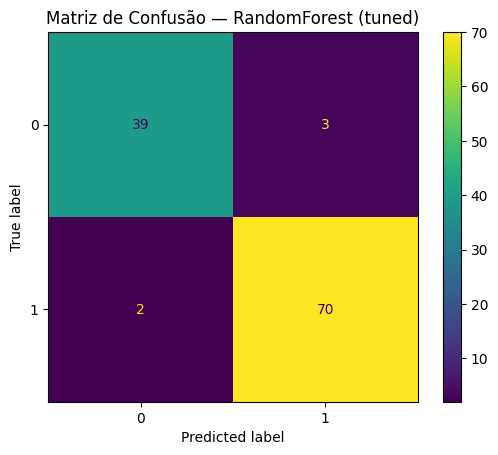

In [ ]:


from sklearn.metrics import classification_report, ConfusionMatrixDisplay

assert PROBLEM_TYPE == "classificacao", "Esta célula foi ajustada para CLASSIFICAÇÃO."

# 1) Pega o melhor modelo disponível
if 'search' in globals() and hasattr(search, "best_estimator_"):
    best_model = search.best_estimator_               # melhor RF (tuned)
    best_name  = "RandomForest (tuned)"
else:
    # fallback simples: escolhe o melhor dos candidatos já treinando agora e compara rápido
    tmp_scores = {}
    for name, pipe in candidates.items():
        pipe.fit(X_train, y_train)
        yp = pipe.predict(X_test)
        pp = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
        tmp_scores[name] = evaluate_classification(y_test, yp, pp)["f1_weighted"]
    best_name  = max(tmp_scores, key=tmp_scores.get)
    best_model = candidates[best_name].fit(X_train, y_train)

print(f"Modelo escolhido para avaliação final: {best_name}")

# 2) Avaliação no teste (dados nunca vistos)
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None
final_metrics = evaluate_classification(y_test, y_pred, y_proba)
print("Métricas no teste:", final_metrics)

# 3) Relatório e matriz de confusão
print("\nClassification report (teste):\n")
print(classification_report(y_test, y_pred, digits=4))

try:
    ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
    plt.title(f"Matriz de Confusão — {best_name}")
    plt.show()
except Exception as e:
    print("Não foi possível plotar a matriz de confusão:", e)




## 9. Engenharia de atributos

Neste projeto não foi necessário criar atributos novos, pois o dataset já vem com 30 variáveis numéricas derivadas de medidas dos tumores.  
As principais decisões foram:

- **Seleção de atributos:** todas as 30 variáveis foram mantidas, sem redução inicial.  
- **Pré-processamento:** aplicado apenas o `StandardScaler` para padronizar as escalas, importante para modelos lineares como a Regressão Logística.  
- **Encoding:** não aplicável (não havia variáveis categóricas).  
- **Features temporais ou de texto/imagem:** não se aplicam ao problema.  

**Resumo:** a engenharia de atributos foi mínima, já que o dataset está estruturado e pronto para classificação.  


## 10. Boas práticas e rastreabilidade

- O baseline foi definido com o DummyClassifier, servindo como ponto de partida para comparação.  
- Logistic Regression e Random Forest foram os modelos candidatos testados e mostraram melhoria clara em relação ao baseline.  
- As etapas de pré-processamento e treino foram organizadas em pipelines, o que ajuda a evitar vazamento de dados.  
- A validação foi feita com StratifiedKFold e o ajuste de parâmetros com RandomizedSearchCV.  
- As principais decisões do projeto (manter todas as features, aplicar StandardScaler, escolha dos modelos) foram registradas.  
- Foi usada uma seed fixa (42) para garantir reprodutibilidade.  

**Resumo:** as boas práticas básicas foram seguidas, deixando o fluxo mais organizado e os resultados mais confiáveis.



## 11. Conclusões e próximos passos

O projeto mostrou que modelos de aprendizado supervisionado conseguem classificar casos de câncer de mama com alta precisão.  
A Regressão Logística e o Random Forest superaram o baseline com folga.  
O Random Forest tuned foi escolhido como modelo final por apresentar bom equilíbrio entre desempenho e robustez.

**Principais pontos observados:**
- Baseline fraco (~0,63 de acurácia), confirmando a importância de modelos mais avançados.  
- Logistic Regression atingiu quase 0,98 de acurácia com treinamento rápido e simples.  
- Random Forest chegou a ~0,96 de acurácia, com AUC próximo de 0,99, mostrando capacidade de capturar relações mais complexas.  
- Trade-off entre simplicidade (LR) e complexidade/tempo de treino (RF).

**Limitações:**
- Base de dados pequena (569 exemplos), sem validação externa.  
- Apenas variáveis numéricas do próprio dataset, sem atributos adicionais.  
- Resultados podem variar em outros cenários ou populações.

**Próximos passos sugeridos:**
- Testar em bases maiores ou diferentes para avaliar generalização.  
- Incluir técnicas de redução de dimensionalidade (ex.: PCA) e explicabilidade (SHAP).  
- Calibrar probabilidades e ajustar limiares de decisão para priorizar recall da classe maligna.  
- Experimentar outros modelos (ex.: XGBoost, LightGBM) e realizar tuning mais aprofundado.  



## 12. Salvando artefatos (modelos e pipeline)

Mesmo com tempo de treino baixo, é útil salvar o modelo final já treinado.  
Isso evita retrabalho e garante que o mesmo artefato possa ser reutilizado depois.  
Foi usado o formato `.pkl` com a biblioteca `joblib`.


In [ ]:
import joblib

# salvar o melhor modelo
joblib.dump(best_model, "modelo_breast_cancer.pkl")

# carregar novamente quando precisar
modelo_carregado = joblib.load("modelo_breast_cancer.pkl")

# verificando
print("Modelo carregado:", type(modelo_carregado))


Modelo carregado: <class 'sklearn.pipeline.Pipeline'>
